# Exploratory Data Analysis (EDA)  
## Customer Churn Prediction – Telecommunications Dataset  



## Introduction  

Customer churn prediction is a critical problem in the telecommunications industry, where retaining existing customers is generally more cost-effective than acquiring new ones. The objective of this project is to develop a predictive analytics model to classify whether a customer will churn based on demographic characteristics, service usage patterns, and billing information.

This exploratory data analysis (EDA) aims to systematically investigate the dataset prior to preprocessing and modelling. The insights obtained from this analysis will guide feature engineering, model selection, and evaluation strategy.

## Exploratory Data Analysis Objectives  

This exploratory data analysis aims to systematically investigate the dataset before model development.  

The key objectives are to:

- Examine dataset structure, dimensionality, and data types  
- Identify missing values, duplicates, and potential data quality issues  
- Analyse numerical feature distributions  
- Examine categorical feature distributions  
- Assess class imbalance in the target variable  
- Identify preliminary relationships between predictors and churn behaviour  

These steps ensure methodological rigor and provide a structured foundation for subsequent preprocessing and modelling.

In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from statsmodels.tools.tools import add_constant

import warnings
warnings.filterwarnings("ignore")

In [4]:
churn_data = pd.read_csv('../data/churn.csv')

In [5]:
churn_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
churn_data.shape

(7043, 21)

## Dataset Overview  
The dataset contains customer-level records from a telecommunications provider and is used for supervised binary classification to predict customer churn.

### Structure  
- **Observations:** 7,043 customers  
- **Variables:** 21 (including target)  
- **Target:** `Churn` (Yes / No)  
Each row represents an individual customer.

### Feature Types  
- **Numerical:** `tenure`, `MonthlyCharges`, `TotalCharges`  
- **Categorical:** demographic, service usage, contract, and billing variables  
- **Identifier:** `customerID` (excluded from modelling)

### Data Notes  
- `SeniorCitizen` is encoded numerically but represents a binary category.  
- `TotalCharges` required conversion to numeric due to blank entries.  

These issues will be handled during preprocessing.

## Target Variable Analysis
This section examines the distribution of the target variable (Churn) to assess class imbalance and its potential impact on model performance.

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


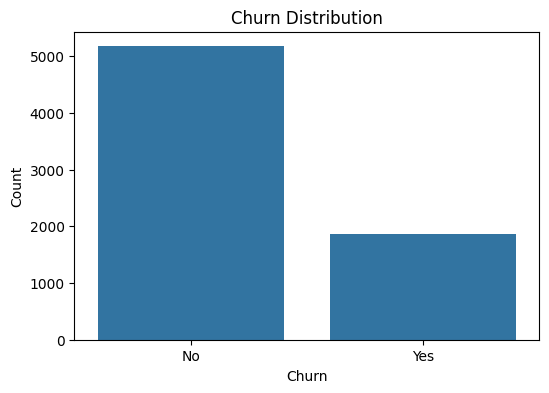

In [8]:
churn_counts = churn_data["Churn"].value_counts()
print(churn_counts)

churn_percent = churn_data["Churn"].value_counts(normalize=True) * 100
print(churn_percent.round(2))

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=churn_data)
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()


The target variable `Churn` is binary (Yes / No).  **No Churn:** ~73%, **Churn:** ~27%  this indicates moderate class imbalance. Therefore, evaluation metrics such as recall, F1-score, and ROC-AUC will be prioritised over overall accuracy during modelling.

## Duplicate Value Check
This step checks whether the dataset contains duplicate records that could bias the analysis and model performance. Removing duplicates ensures data integrity and more reliable modelling results.

In [9]:
churn_data.duplicated().sum()

np.int64(0)

In [10]:
churn_data = churn_data.drop_duplicates(ignore_index=True)

In [11]:
churn_data.shape

(7043, 21)

The duplicate value check shows that the dataset contains no duplicate records. Therefore, no observations were removed, and the original dataset structure (7043 rows and 21 columns) was retained for further analysis.

## Missing Value Analysis
This section examines the dataset for missing values and potential data quality issues. Identifying missing or improperly formatted values is essential to ensure accurate preprocessing and reliable model performance.

In [12]:
churn_data.isnull().sum().sort_values(ascending=False)

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
OnlineBackup        0
gender              0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
SeniorCitizen       0
Churn               0
dtype: int64

Text(0, 0.5, 'Observations')

<Figure size 1200x600 with 0 Axes>

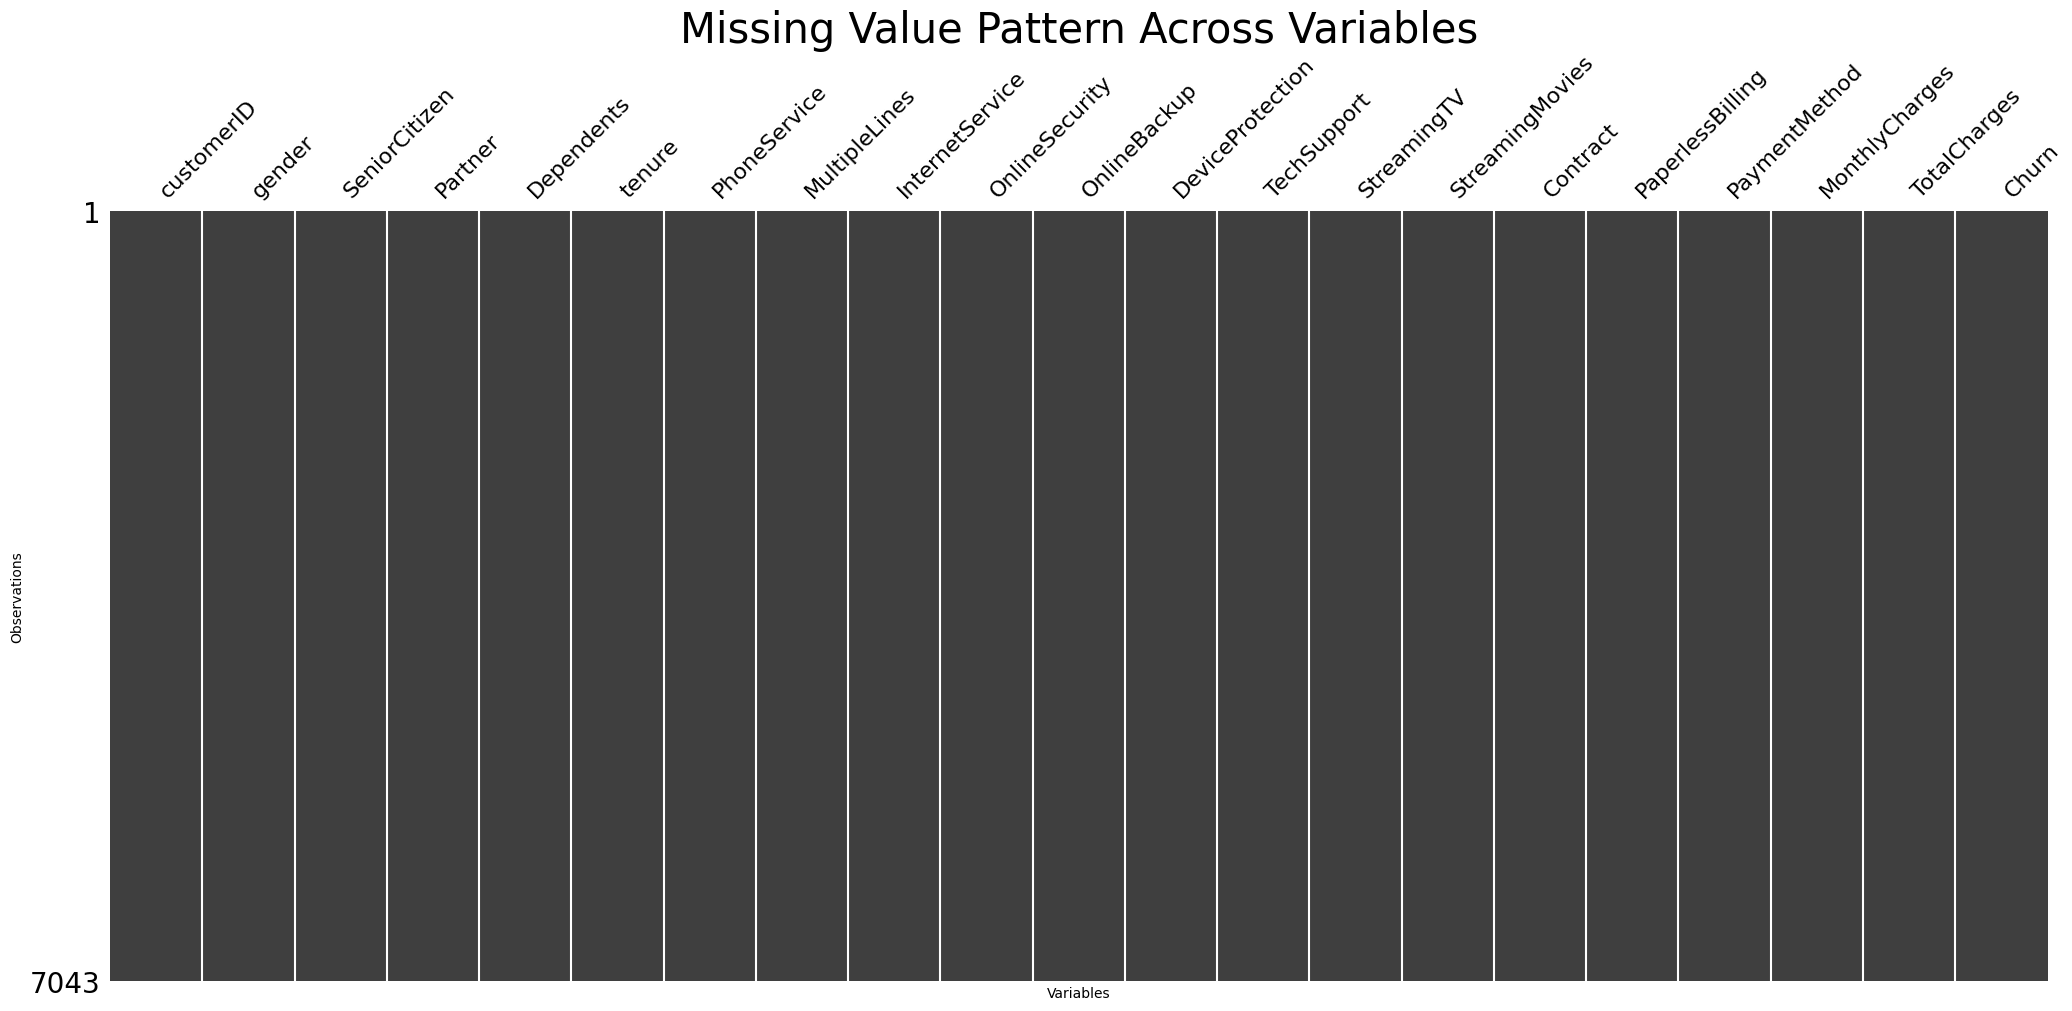

In [13]:
plt.figure(figsize=(12, 6))
msno.matrix(churn_data, sparkline=False)

plt.title("Missing Value Pattern Across Variables", fontsize=30)
plt.xlabel("Variables")
plt.ylabel("Observations")

Initial inspection showed no explicit null values. However, after converting `TotalCharges` to numeric format, 11 missing values were identified due to blank entries. These observations will be handled during preprocessing to ensure model robustness.

## Numerical Feature Distribution

### Descriptive Statistic

In [14]:
churn_data['SeniorCitizen'] = churn_data['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

In [15]:
churn_data["TotalCharges"] = pd.to_numeric(churn_data["TotalCharges"], errors="coerce")

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
churn_data[num_cols].describe()

# churn_data.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


### Histogram

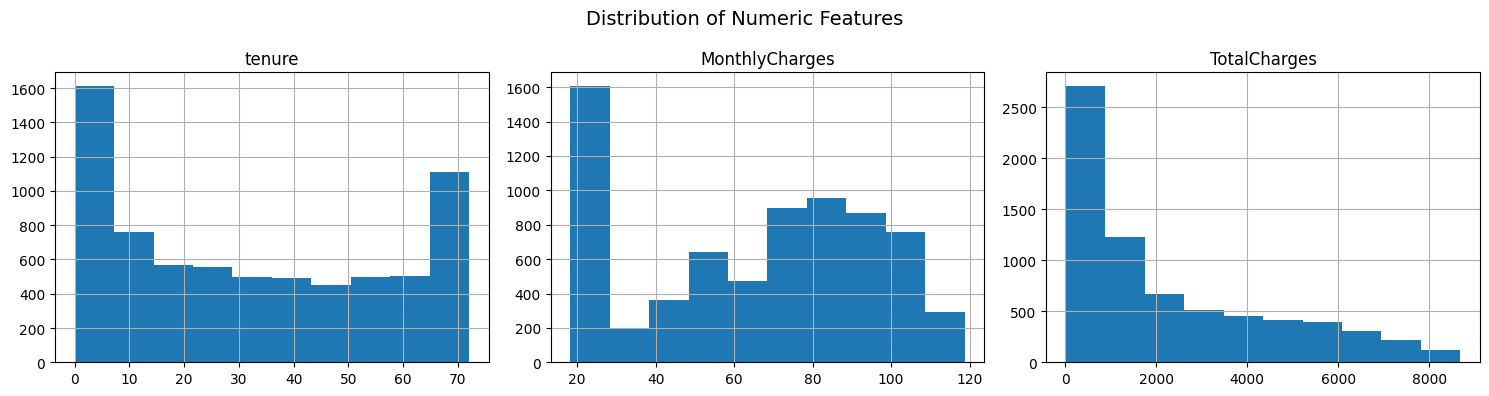

In [16]:
churn_data[num_cols].hist(figsize=(15, 4), layout=(1, 3))

plt.suptitle('Distribution of Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

**Descriptive statistics indicate:**

* The median **tenure** is approximately **29 months**, suggesting many customers have remained with the service for around two to three years.
* **MonthlyCharges** has a mean of approximately **$64.76** (range: **$18.25–$118.75**), indicating moderate variation in monthly pricing across customers.
* **TotalCharges** is **right-skewed**, with a median of approximately **$1,397.48** and a maximum of approximately **$8,684.80**, reflecting accumulated spending over time (and its strong relationship with tenure).

## Categorical Feature Distribution

The dataset contains multiple categorical variables describing customer demographics, subscribed services, and billing characteristics. These variables were analysed using frequency distributions and churn-based comparisons.

In [17]:
cat_cols = churn_data.select_dtypes(include='object').columns.tolist()
cat_cols.remove('customerID')
cat_cols.remove('Churn')
cat_cols

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [18]:
binary_cols = []
other_cols = []

for col in cat_cols:
    if churn_data[col].nunique() == 2:
        binary_cols.append(col)
    else:
        other_cols.append(col)

print("Binary Columns:", binary_cols)
print("Other Categorical Columns:", other_cols)


Binary Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Other Categorical Columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


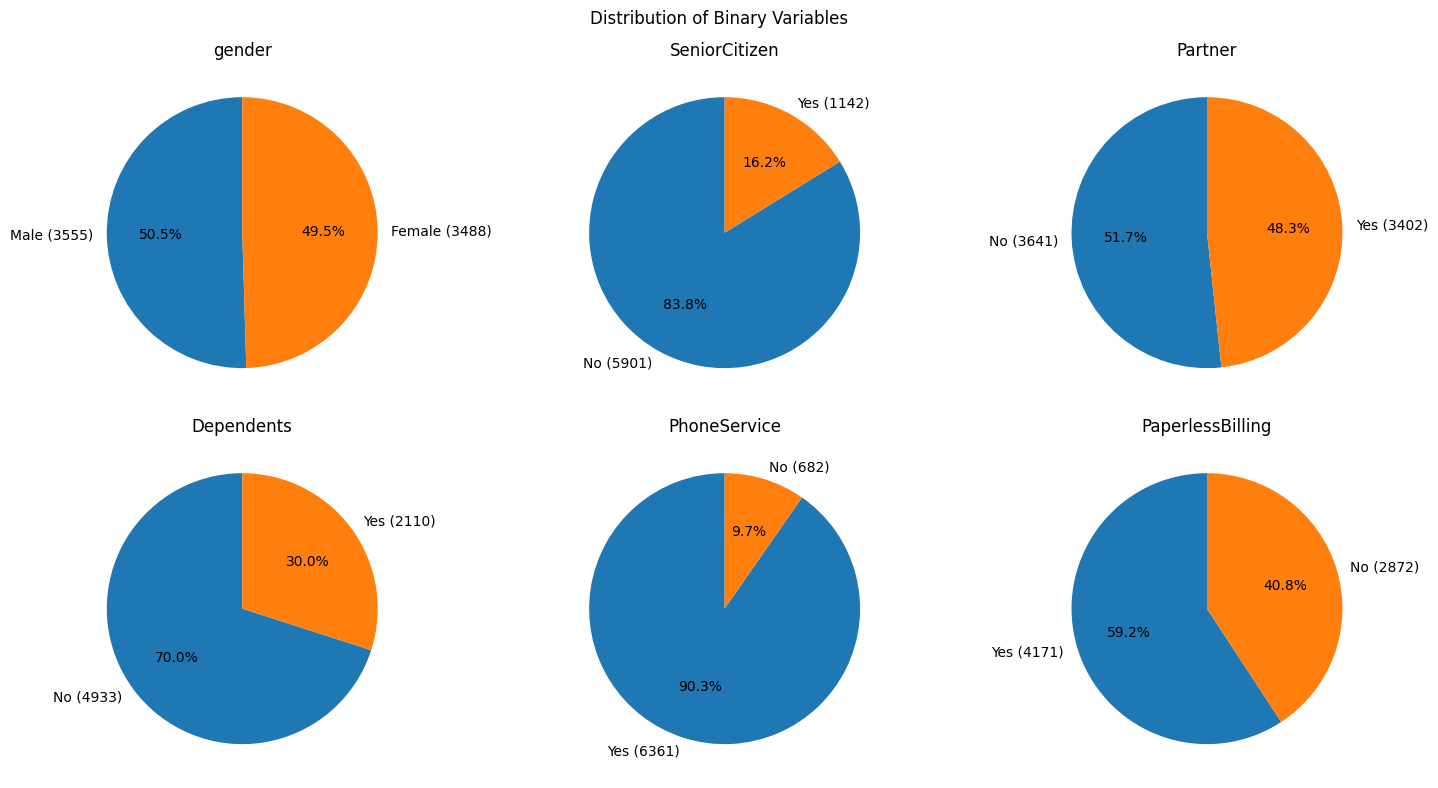

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    counts = churn_data[col].value_counts()
    
    axes[i].pie(
        counts.values,
        labels=[f"{k} ({v})" for k, v in zip(counts.index, counts.values)],
        autopct='%1.1f%%',
        startangle=90
    )
    axes[i].set_title(col)

plt.suptitle("Distribution of Binary Variables")
plt.tight_layout()
plt.show()


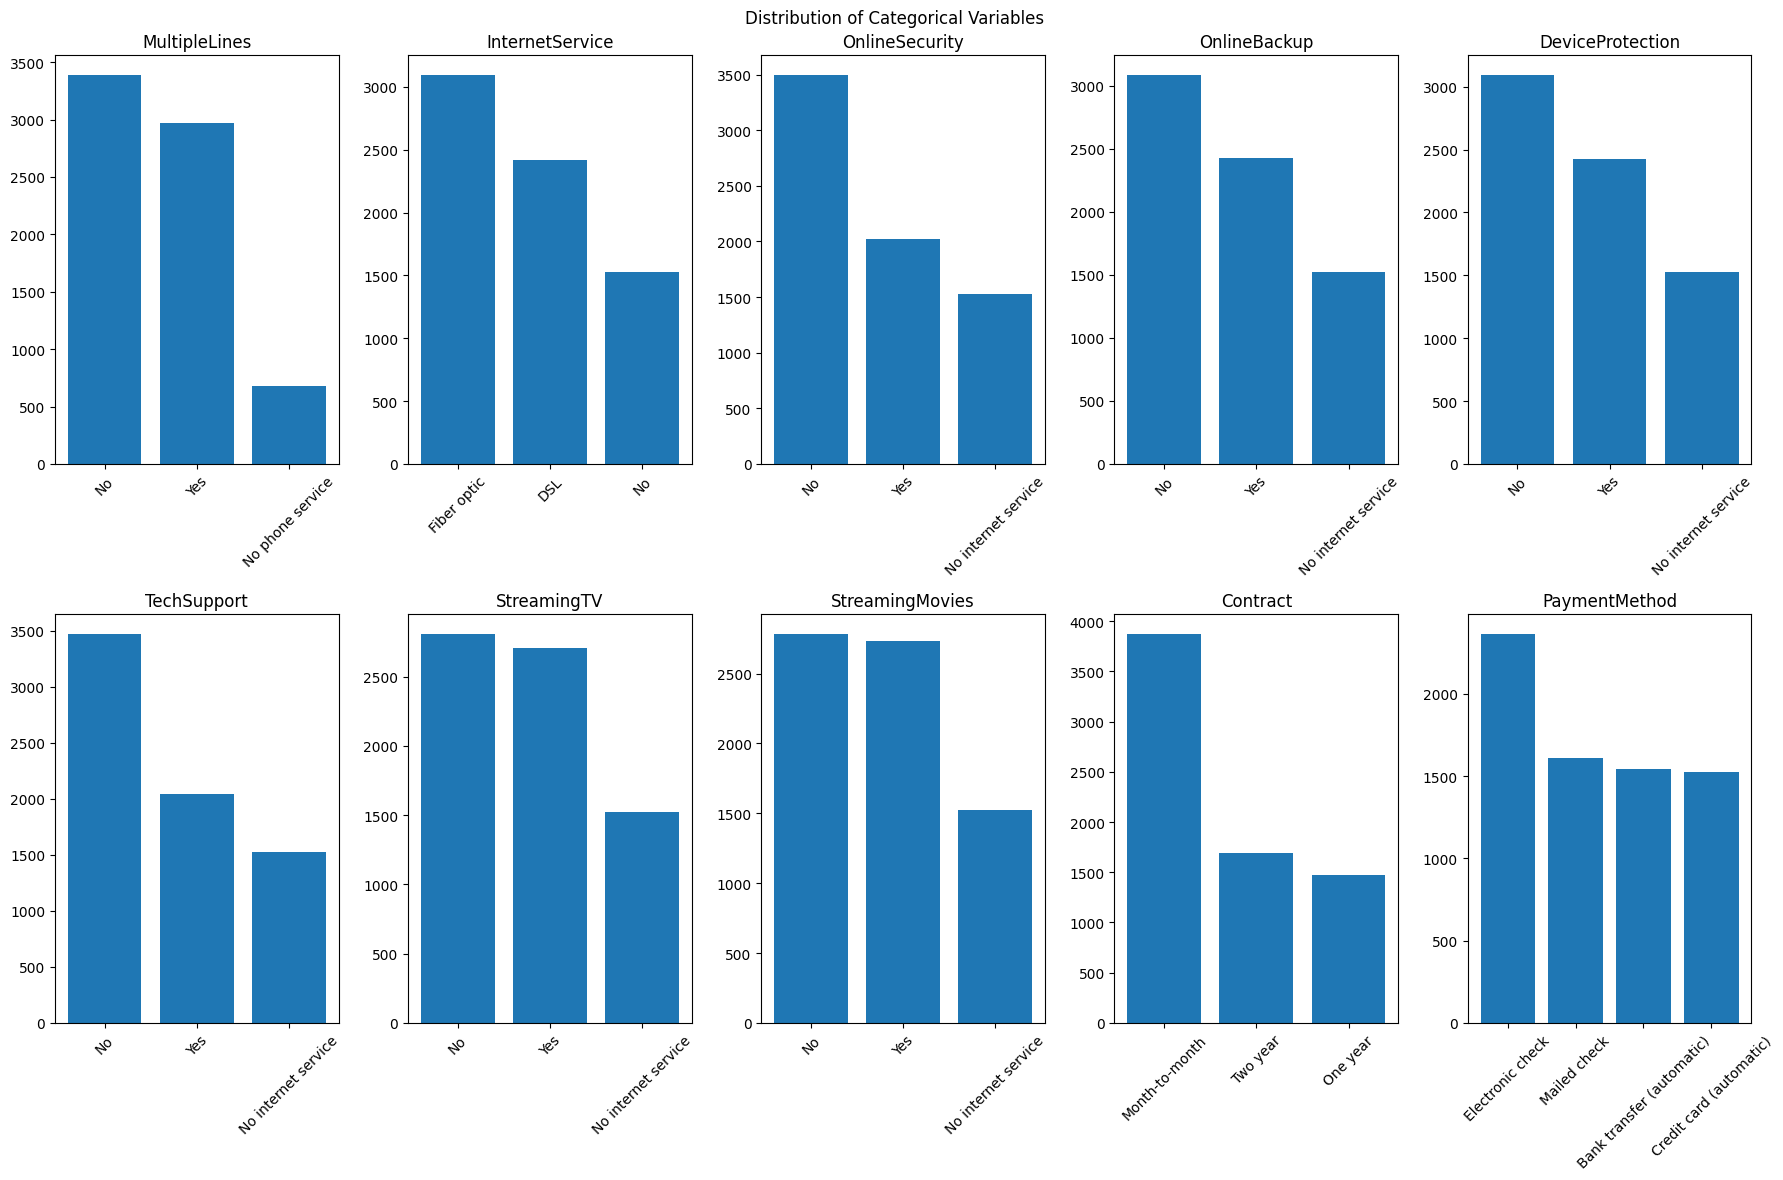

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(other_cols):
    counts = churn_data[col].value_counts()
    
    axes[i].bar(counts.index, counts.values)
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Distribution of Categorical Variables")
plt.tight_layout()
plt.show()

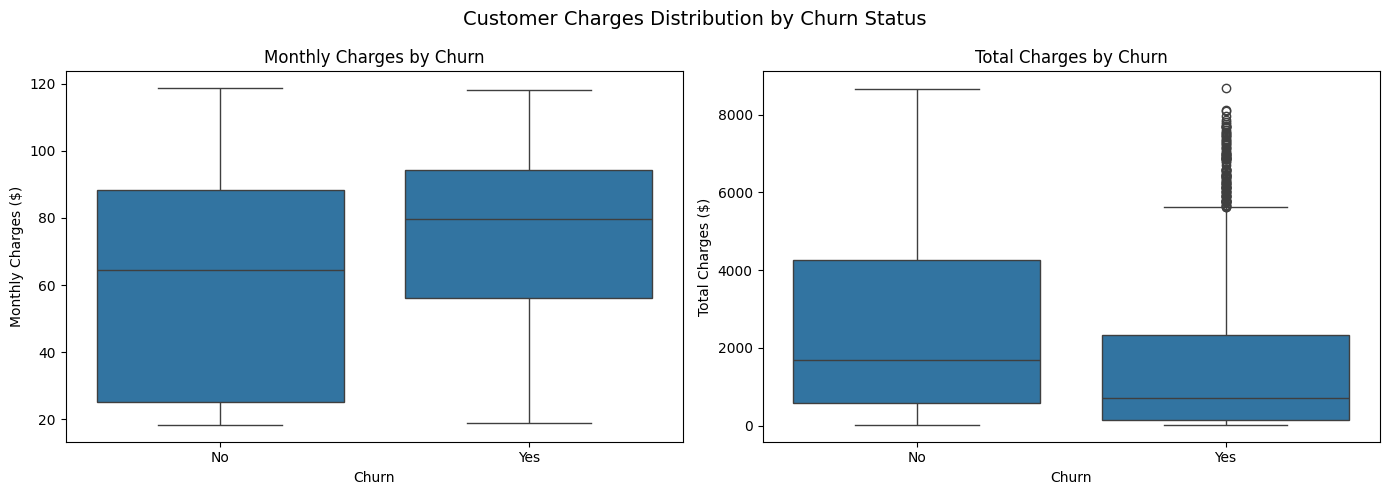

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Churn', y='MonthlyCharges',data=churn_data,ax=axes[0])

axes[0].set_title('Monthly Charges by Churn')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Monthly Charges ($)')

sns.boxplot(x='Churn', y='TotalCharges', data=churn_data, ax=axes[1])

axes[1].set_title('Total Charges by Churn')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Total Charges ($)')

plt.suptitle('Customer Charges Distribution by Churn Status', fontsize=14)
plt.tight_layout()
plt.show()

Boxplot analysis indicates that:

- Customers who churn tend to have higher monthly charges.
- Churned customers generally have lower total charges, reflecting shorter service duration.
- Longer tenure is associated with lower churn probability.

These findings suggest that `tenure`, `MonthlyCharges`, and `TotalCharges` are likely to be important predictors in the churn classification model.

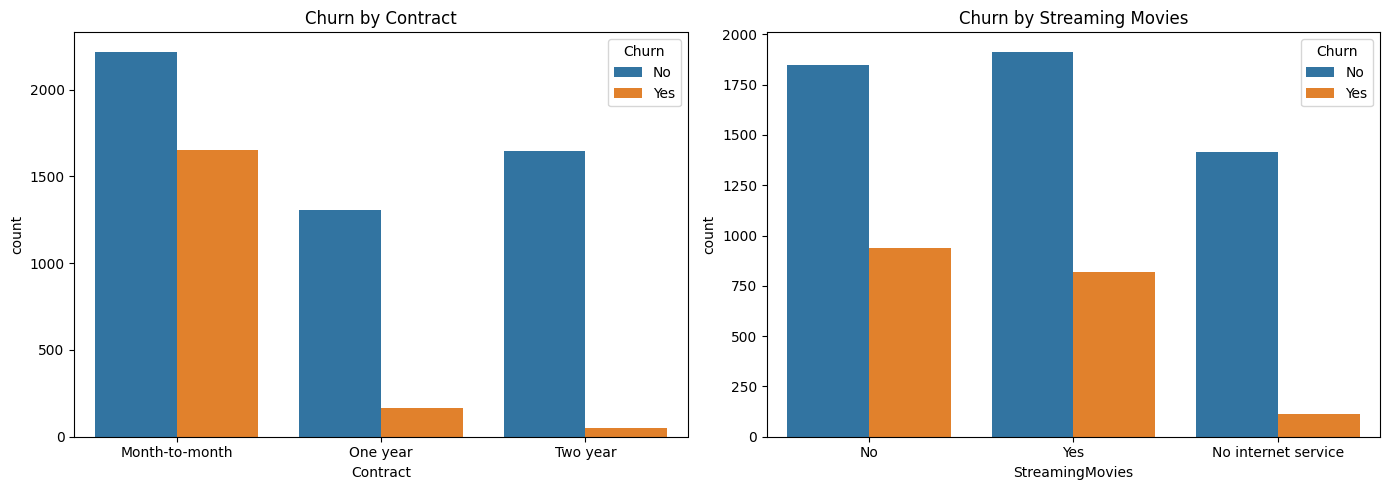

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Contract', hue='Churn', data=churn_data, ax=axes[0])
axes[0].set_title('Churn by Contract')

sns.countplot(x='StreamingMovies', hue='Churn', data=churn_data, ax=axes[1])
axes[1].set_title('Churn by Streaming Movies')

plt.tight_layout()
plt.show()

The analysis shows that contract type has a strong influence on churn behavior, with month-to-month customers exhibiting the highest churn rates and two-year contract customers demonstrating the strongest retention. Additionally, customers without internet service show significantly lower churn rates. However, the presence of streaming services alone does not appear to be a strong standalone predictor of churn.

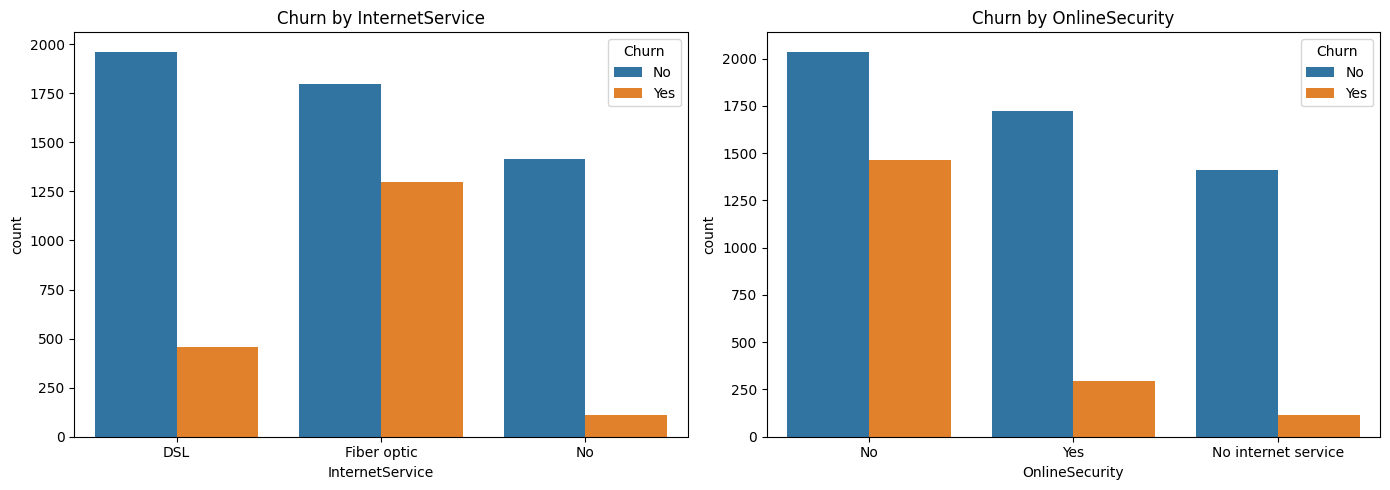

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='InternetService', hue='Churn', data=churn_data, ax=axes[0])
axes[0].set_title('Churn by InternetService')

sns.countplot(x='OnlineSecurity', hue='Churn', data=churn_data, ax=axes[1])
axes[1].set_title('Churn by OnlineSecurity')

plt.tight_layout()
plt.show()

The bar charts indicate that customers with fiber optic internet have the highest churn rates, possibly due to higher monthly costs and service expectations. Additionally, customers without online security show significantly higher churn compared to those with security services.

In [24]:
def plot_swarm_churn(dataset, feature1, feature2, title, fsize=(18,5)):
    fig, ax = plt.subplots(figsize=fsize)
    ax.grid(True)
    
    sns.swarmplot(x=feature1,y=feature2,hue='Churn',data=dataset,size=6)
    
    plt.title(title)
    plt.tight_layout()
    plt.show()

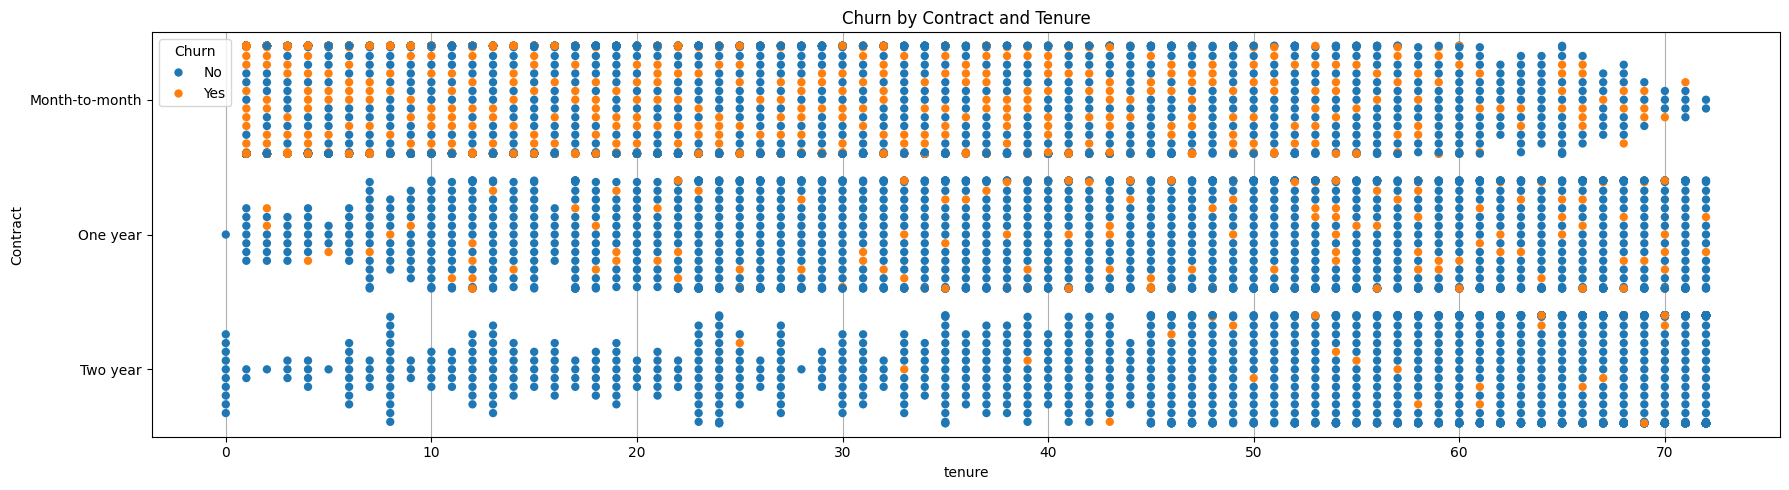

In [25]:
plot_swarm_churn(churn_data, 'tenure', 'Contract',
                 'Churn by Contract and Tenure')

The scatter analysis indicates that tenure does not significantly reduce churn risk for month-to-month customers. In contrast, customers on one-year and two-year contracts demonstrate substantially lower churn, particularly at higher tenure levels. This suggests that contractual commitment plays a stronger retention role than tenure alone.

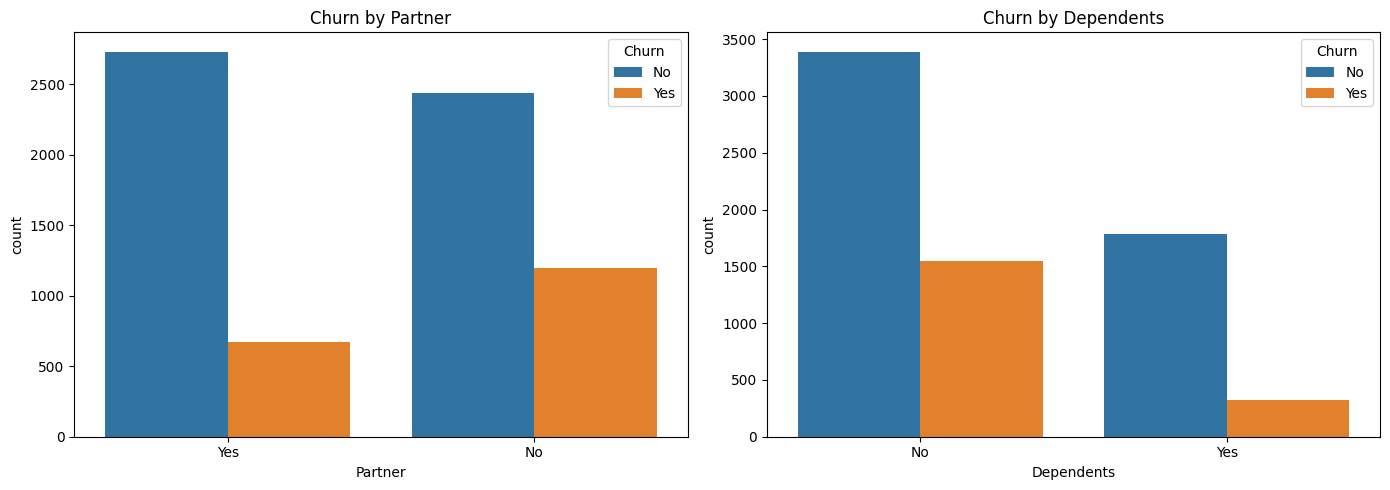

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Partner', hue='Churn', data=churn_data, ax=axes[0])
axes[0].set_title('Churn by Partner')

sns.countplot(x='Dependents', hue='Churn', data=churn_data, ax=axes[1])
axes[1].set_title('Churn by Dependents')

plt.tight_layout()
plt.show()

The analysis indicates that customers without partners and dependents are more likely to churn. This suggests that single customers or those without family responsibilities may have lower service commitment and higher switching behavior compared to customers with partners or dependents.

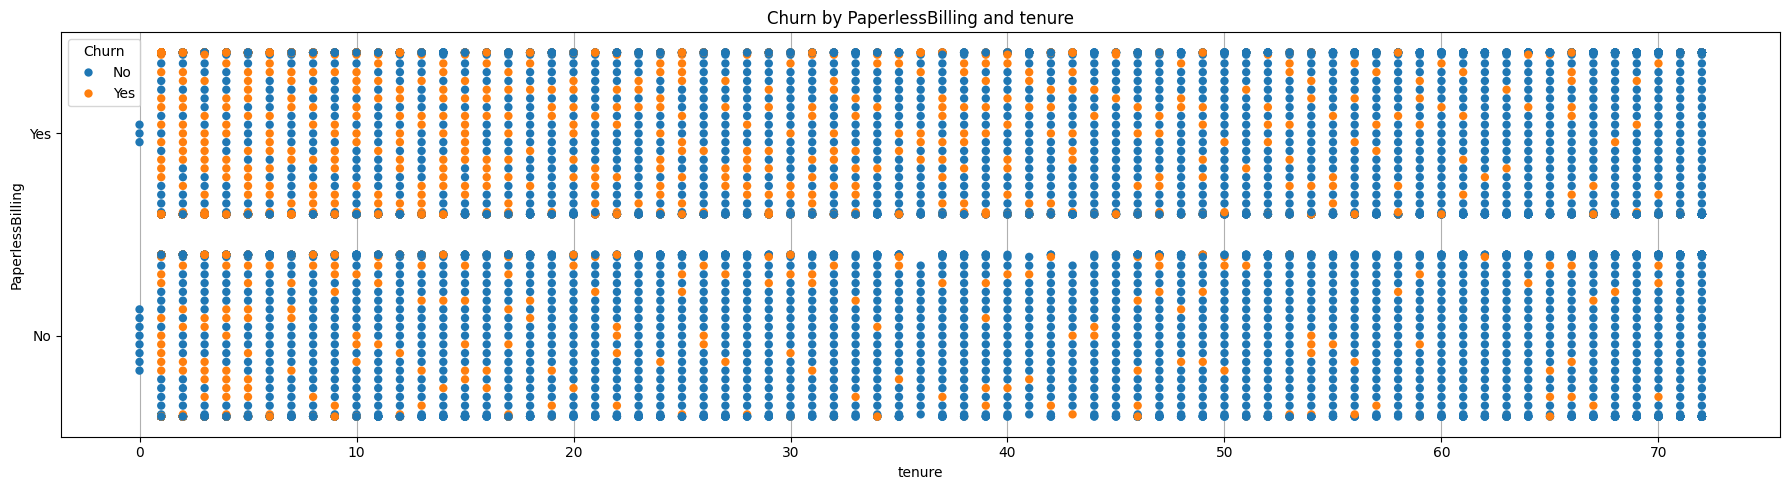

In [27]:
plot_swarm_churn(churn_data, 'tenure', 'PaperlessBilling', 'Churn by PaperlessBilling and tenure')

Customers with low tenure who use paperless billing exhibit higher churn rates compared to other groups. However, as tenure increases, churn significantly decreases regardless of billing method.

In [28]:
churn_data.groupby(['DeviceProtection', 'StreamingMovies']).agg({'MonthlyCharges': 'mean'})

MonthlyCharges
DeviceProtection    StreamingMovies                    
No                  No                        62.804443
                    Yes                       84.027397
No internet service No internet service       21.079194
Yes                 No                        71.660218
                    Yes                       91.646708

## Correlation Analysis

In [29]:
churn_corr = churn_data.copy()

for col in churn_corr.columns:
    if churn_corr[col].dtype == 'object' and churn_corr[col].nunique() == 2:
        churn_corr[col] = churn_corr[col].map({'Yes': 1, 'No': 0})

churn_corr.drop('gender', axis=1, inplace=True)

In [30]:
def correlation_heatmap(df):
    fig, ax = plt.subplots(figsize=(14, 12))
    colormap = sns.diverging_palette(220, 10, as_cmap=True)

    corr = df.select_dtypes(include='number').corr()

    sns.heatmap(
        corr,
        cmap=colormap,
        square=True,
        cbar_kws={'shrink': .9},
        ax=ax,
        annot=True,
        linewidths=0.1,
        vmax=1.0,
        linecolor='white',
        annot_kws={'fontsize': 12}
    )

    plt.title('Pearson Correlation of Numeric and Binary Features', y=1.05, size=15)
    plt.show()

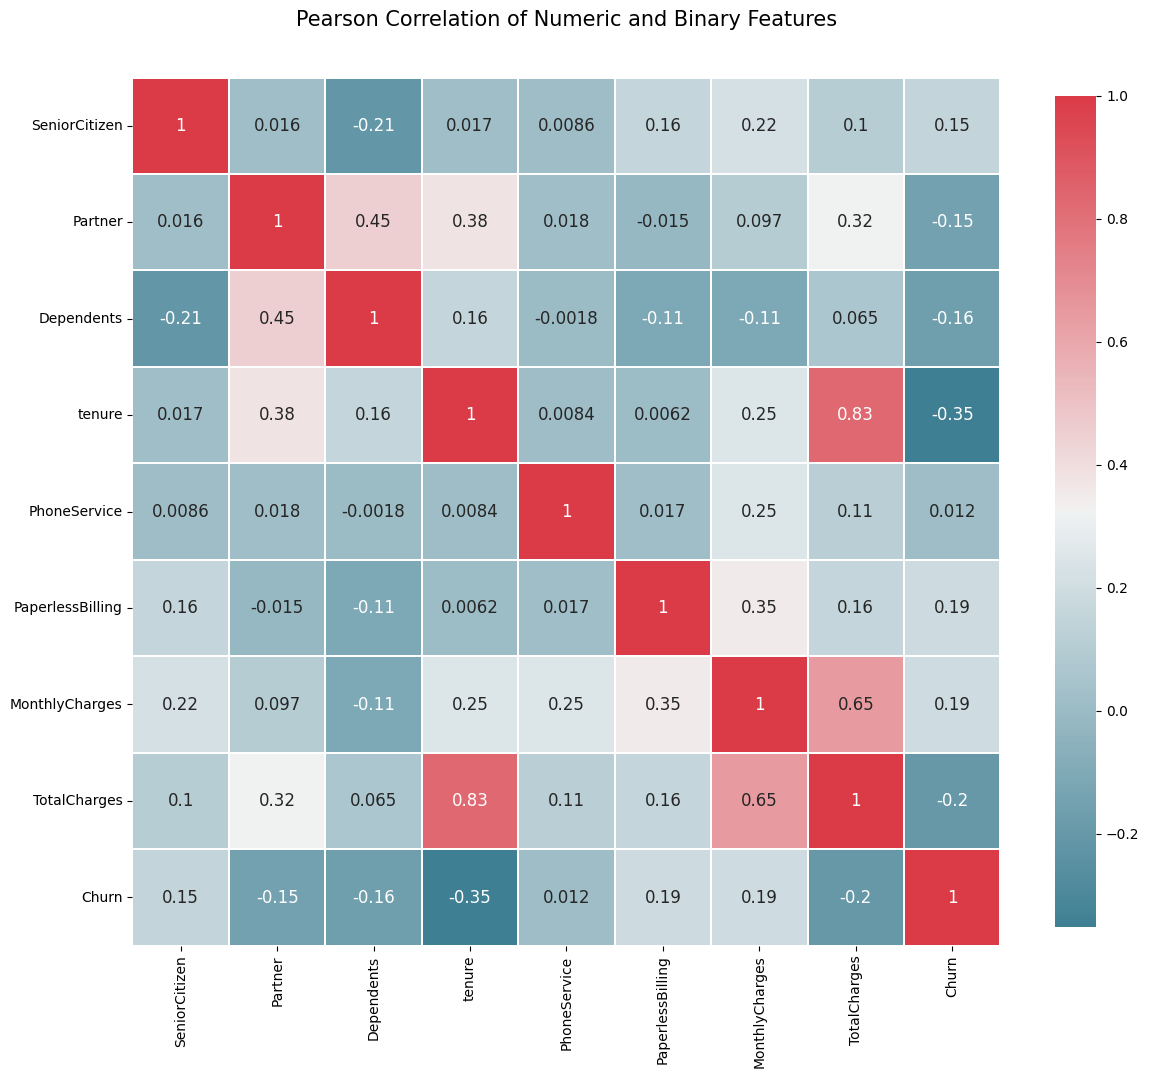

In [31]:
correlation_heatmap(churn_corr)

Key findings:

- `tenure` and `TotalCharges` show a strong positive correlation, which is expected since total expenditure accumulates over time.
- `MonthlyCharges` has a moderate positive correlation with churn.
- `tenure` has a negative relationship with churn, indicating that longer-term customers are less likely to leave.

Due to the strong relationship between `tenure` and `TotalCharges`, multicollinearity will be considered during model selection.

## Overall EDA Summary  

The exploratory analysis revealed several important patterns:

1. **Class Imbalance:**  
   Churn represents approximately 27% of the dataset, requiring careful metric selection.

2. **Key Numerical Drivers:**  
   - Short tenure is associated with higher churn.  
   - Higher monthly charges increase churn likelihood.  

3. **Key Categorical Drivers:**  
   - Month-to-Month contracts show significantly higher churn.  
   - Lack of OnlineSecurity and TechSupport increases churn probability.  
   - Electronic Check payment method is associated with higher churn.

4. **Data Quality:**  
   - Minimal missing values (11 in `TotalCharges`).  
   - No duplicate records.  
   - Minor type corrections required.
   - No extreme or erroneous outliers were identified in the dataset.


## Implications for Modelling  

Based on the EDA:

- Feature encoding will be required for categorical variables.  
- Class imbalance should be addressed using appropriate evaluation metrics.  
- Regularisation or feature selection may be necessary due to correlated numerical features.

This concludes the exploratory phase and provides a structured foundation for preprocessing and predictive modelling.